#Weather Image Classification using Improved CNN
**Dataset:** 11-class weather dataset từ Google Drive  
**Image size:** 300x300  
**Split:** 80% Train / 20% Validation

## 1. Mount Google Drive & Kiểm tra Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/dataset'

# Liệt kê các class (folder) trong dataset
classes = sorted([d for d in os.listdir(DATASET_PATH)
                  if os.path.isdir(os.path.join(DATASET_PATH, d))])
print(f"Số lượng class: {len(classes)}")
print(f"Các class: {classes}")

# Đếm số ảnh mỗi class
print("\nSố ảnh mỗi class:")
total = 0
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
    print(f"  {cls}: {len(imgs)} ảnh")
    total += len(imgs)
print(f"\nTổng cộng: {total} ảnh")

Số lượng class: 12
Các class: ['.ipynb_checkpoints', 'dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']

Số ảnh mỗi class:
  .ipynb_checkpoints: 0 ảnh
  dew: 698 ảnh
  fogsmog: 851 ảnh
  frost: 475 ảnh
  glaze: 639 ảnh
  hail: 591 ảnh
  lightning: 377 ảnh
  rain: 526 ảnh
  rainbow: 232 ảnh
  rime: 1160 ảnh
  sandstorm: 706 ảnh
  snow: 621 ảnh

Tổng cộng: 6876 ảnh


## 2. Cài đặt thư viện & Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


## 3. Cấu hình Hyperparameters

In [ ]:
# ===== CẤU HÌNH =====
IMG_SIZE     = 300          # Kích thước ảnh 300x300
BATCH_SIZE   = 32
EPOCHS       = 50
NUM_CLASSES  = 11
SEED         = 42
VAL_SPLIT    = 0.2          # 20% validation
LEARNING_RATE = 1e-3
DROPOUT_RATE  = 0.4
L2_REG        = 1e-4

MODEL_SAVE_PATH = '/content/drive/MyDrive/weather_cnn_best.keras'

print("Cấu hình đã được thiết lập!")

Cấu hình đã được thiết lập!


## 4. Data Augmentation & Chuẩn bị Dataset

In [ ]:
# Data augmentation cho tập train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation chỉ rescale, không augment
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"\nClasses: {CLASS_NAMES}")
print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 5504 images belonging to 11 classes.
Found 1372 images belonging to 11 classes.

Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
Train samples: 5504
Validation samples: 1372


## 5. Visualize một số ảnh mẫu

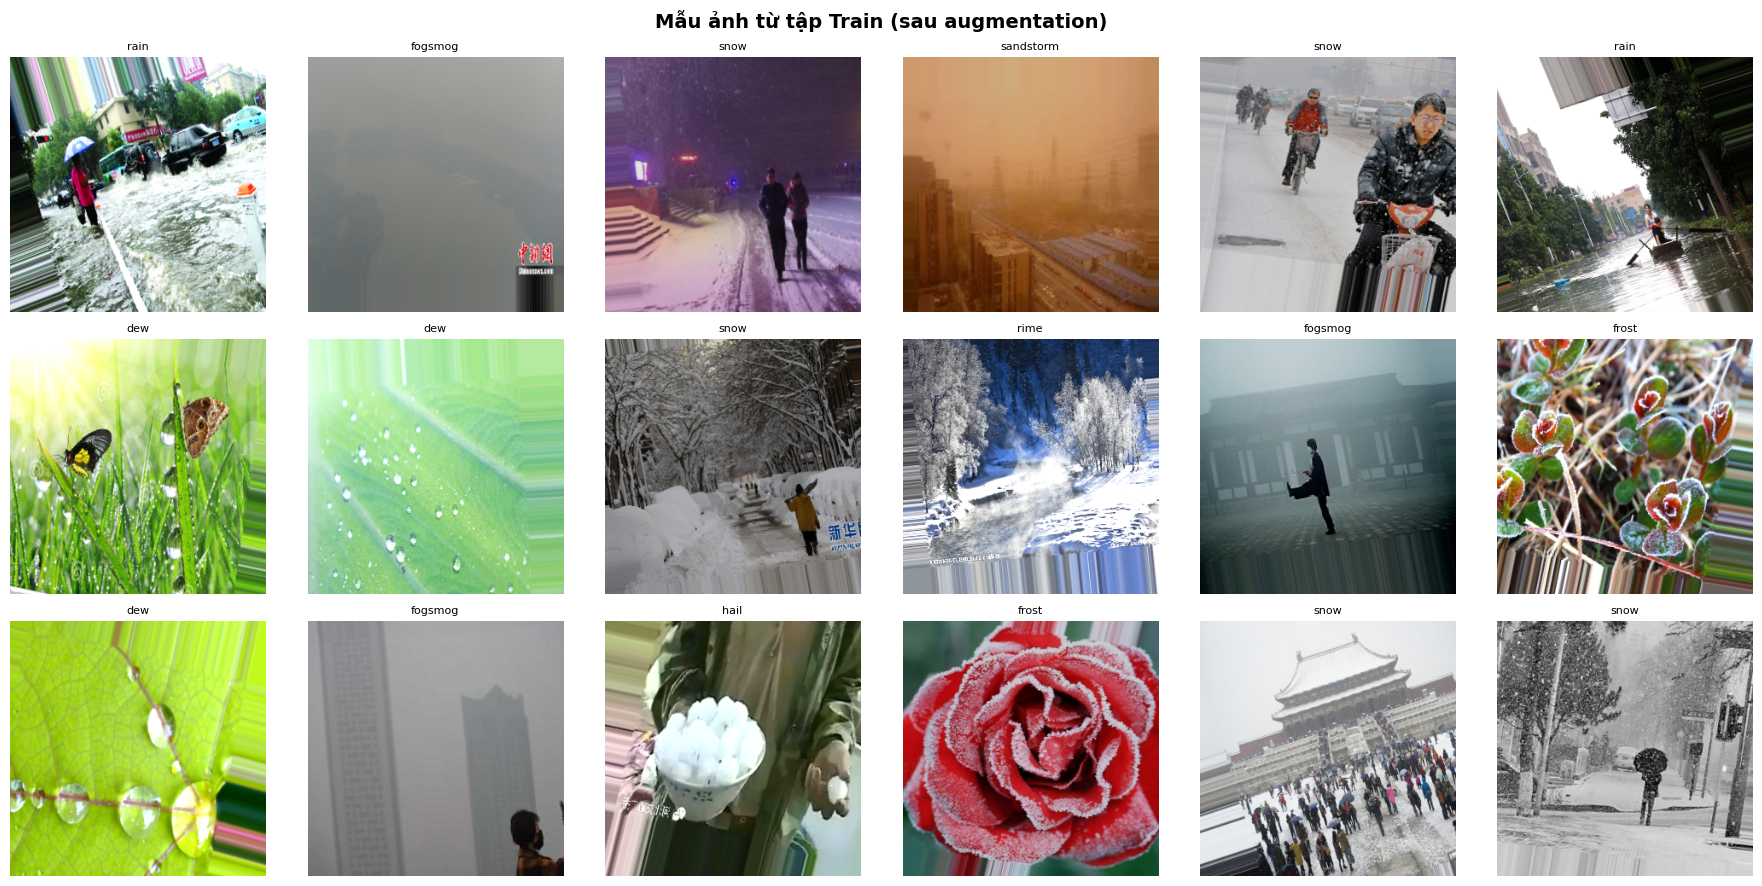

In [ ]:
images, labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Mẫu ảnh từ tập Train (sau augmentation)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        label_idx = np.argmax(labels[i])
        ax.set_title(CLASS_NAMES[label_idx], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Xây dựng Mô hình CNN Cải tiến

Kiến trúc sử dụng:
- **Depthwise Separable Convolution** (tiết kiệm tham số)
- **Residual-style skip connections** (tránh vanishing gradient)
- **Batch Normalization** sau mỗi conv
- **Global Average Pooling** thay vì Flatten
- **L2 Regularization + Dropout** (chống overfitting)

In [ ]:
def conv_block(x, filters, kernel_size=3, strides=1, use_residual=False):
    """Conv Block: Conv -> BN -> ReLU (với tùy chọn residual)"""
    shortcut = x

    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding='same',
        kernel_regularizer=regularizers.l2(L2_REG), use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
        filters, kernel_size, padding='same',
        kernel_regularizer=regularizers.l2(L2_REG), use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)

    # Residual connection
    if use_residual:
        if shortcut.shape[-1] != filters or strides != 1:
            shortcut = layers.Conv2D(
                filters, 1, strides=strides, padding='same', use_bias=False
            )(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])

    x = layers.Activation('relu')(x)
    return x


def build_improved_cnn(input_shape=(300, 300, 3), num_classes=11):
    inputs = keras.Input(shape=input_shape)

    # ── Stage 1: Stem ──────────────────────────────────────────
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)  # 150x150
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 75x75

    # ── Stage 2: 128 filters ────────────────────────────────────
    x = conv_block(x, 128, use_residual=True)  # 75x75
    x = layers.MaxPooling2D(2)(x)              # 37x37
    x = layers.Dropout(0.2)(x)

    # ── Stage 3: 256 filters ────────────────────────────────────
    x = conv_block(x, 256, use_residual=True)  # 37x37
    x = layers.MaxPooling2D(2)(x)              # 18x18
    x = layers.Dropout(0.25)(x)

    # ── Stage 4: 512 filters ────────────────────────────────────
    x = conv_block(x, 512, use_residual=True)  # 18x18
    x = layers.MaxPooling2D(2)(x)              # 9x9
    x = layers.Dropout(0.3)(x)

    # ── Stage 5: 512 filters ────────────────────────────────────
    x = conv_block(x, 512, use_residual=True)  # 9x9
    x = layers.Dropout(0.3)(x)

    # ── Head ────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='WeatherCNN_Improved')
    return model


model = build_improved_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "WeatherCNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 150, 150,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 150,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 150, 150,  │     18,432 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 75, 75,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 75, 75,    │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 75, 75,    │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 75, 75,    │      8,192 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 75, 75,    │          0 │ add[0][0]       

 Total params: 9,969,899 (38.03 MB)

 Trainable params: 9,960,747 (38.00 MB)

 Non-trainable params: 9,152 (35.75 KB)

## 7. Compile Mô hình

In [ ]:
optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    weight_decay=1e-5
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print(f"Tổng tham số: {model.count_params():,}")

Tổng tham số: 9,969,899


## 8. Callbacks

In [ ]:
callbacks = [
    # Lưu model tốt nhất theo val_accuracy
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Giảm LR khi val_loss không cải thiện
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    # Dừng sớm nếu val_accuracy không cải thiện
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks đã sẵn sàng!")

Callbacks đã sẵn sàng!


## 9. Huấn luyện Mô hình

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\nHuấn luyện hoàn tất!")

Epoch 1/10
 74/172 ━━━━━━━━━━━━━━━━━━━━ 39:26 24s/step - accuracy: 0.3802 - loss: 2.3326 - precision: 0.5886 - recall: 0.2321

KeyboardInterrupt: 

## 10. Vẽ đồ thị Loss & Accuracy

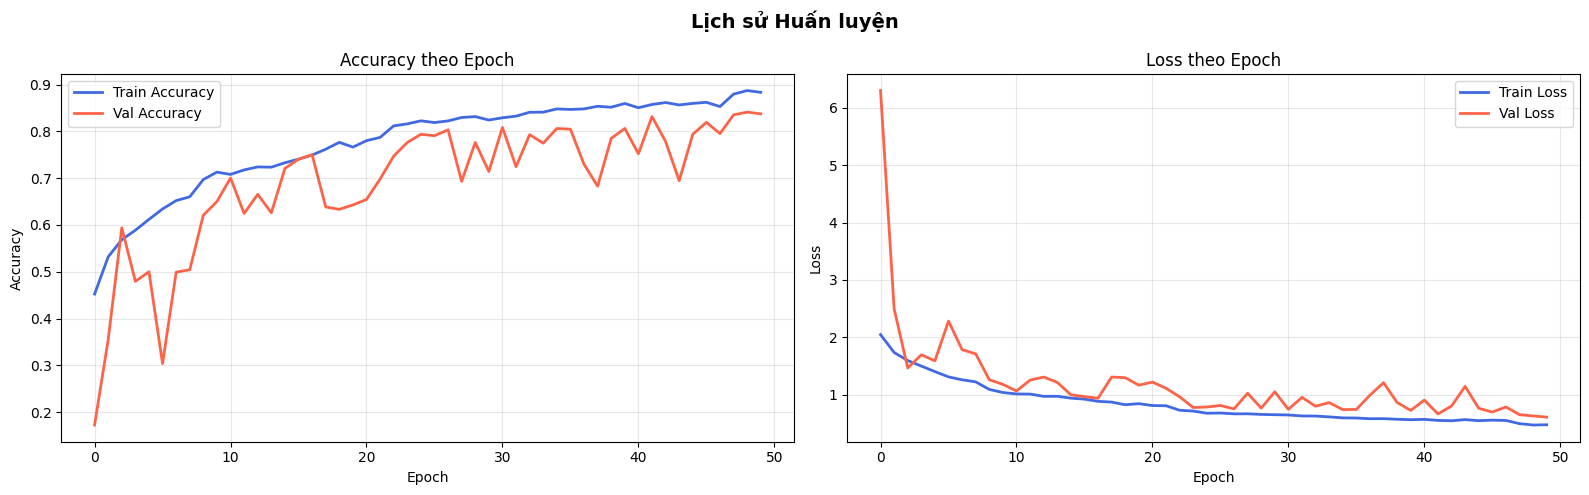

Đã lưu biểu đồ tại /content/training_history.png


In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Lịch sử Huấn luyện', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato', linewidth=2)
    axes[0].set_title('Accuracy theo Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='tomato', linewidth=2)
    axes[1].set_title('Loss theo Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu biểu đồ tại /content/training_history.png")

plot_history(history)

## 11. Đánh giá Mô hình (Metrics đầy đủ)

In [ ]:
# Reset generator về đầu để predict
val_generator.reset()

# Predict toàn bộ validation set
print("Đang dự đoán validation set...")
y_pred_proba = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_generator.classes

print(f"\nSố mẫu validation: {len(y_true)}")
print(f"Classes: {CLASS_NAMES}")

Đang dự đoán validation set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step

Số mẫu validation: 1372
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [ ]:
# ── Metrics tổng quát ──────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("=" * 50)
print("       KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("=" * 50)
print(f"  Accuracy  (tổng): {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (weighted): {precision:.4f}")
print(f"  Recall    (weighted): {recall:.4f}")
print(f"  F1-Score  (weighted): {f1:.4f}")
print("=" * 50)

# ── Classification Report (per-class) ─────────────────────────────
print("\nClassification Report (Accuracy / Precision / Recall / F1 / Support theo từng class):")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

       KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
  Accuracy  (tổng): 0.8411  (84.11%)
  Precision (weighted): 0.8445
  Recall    (weighted): 0.8411
  F1-Score  (weighted): 0.8369

Classification Report (Accuracy / Precision / Recall / F1 / Support theo từng class):
              precision    recall  f1-score   support

         dew     0.8000    0.9209    0.8562       139
     fogsmog     0.8291    0.9706    0.8943       170
       frost     0.8136    0.5053    0.6234        95
       glaze     0.6490    0.7717    0.7050       127
        hail     0.9554    0.9068    0.9304       118
   lightning     0.9868    1.0000    0.9934        75
        rain     0.9263    0.8381    0.8800       105
     rainbow     0.9767    0.9130    0.9438        46
        rime     0.8367    0.8836    0.8595       232
   sandstorm     0.9007    0.9007    0.9007       141
        snow     0.7802    0.5726    0.6605       124

    accuracy                         0.8411      1372
   macro avg     0.8595    0.8348    0.8407    

## 12. Confusion Matrix

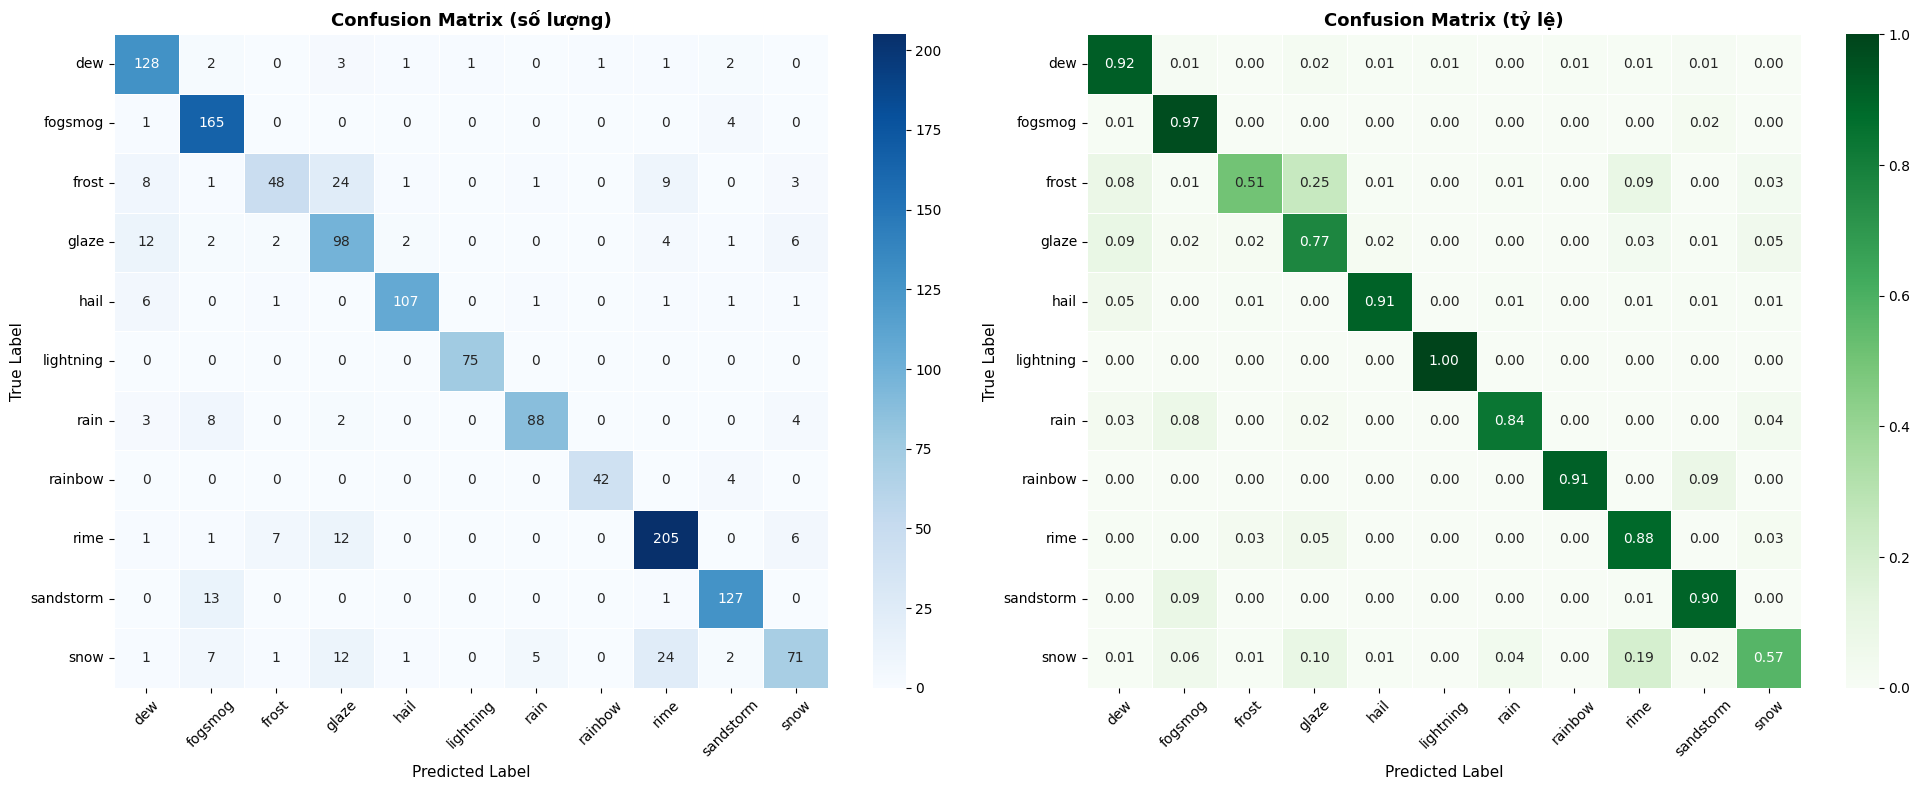

Đã lưu confusion matrix tại /content/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix (số lượng)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (số lượng)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Confusion Matrix (tỷ lệ %)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (tỷ lệ)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu confusion matrix tại /content/confusion_matrix.png")

## 13. Biểu đồ Metrics theo từng Class

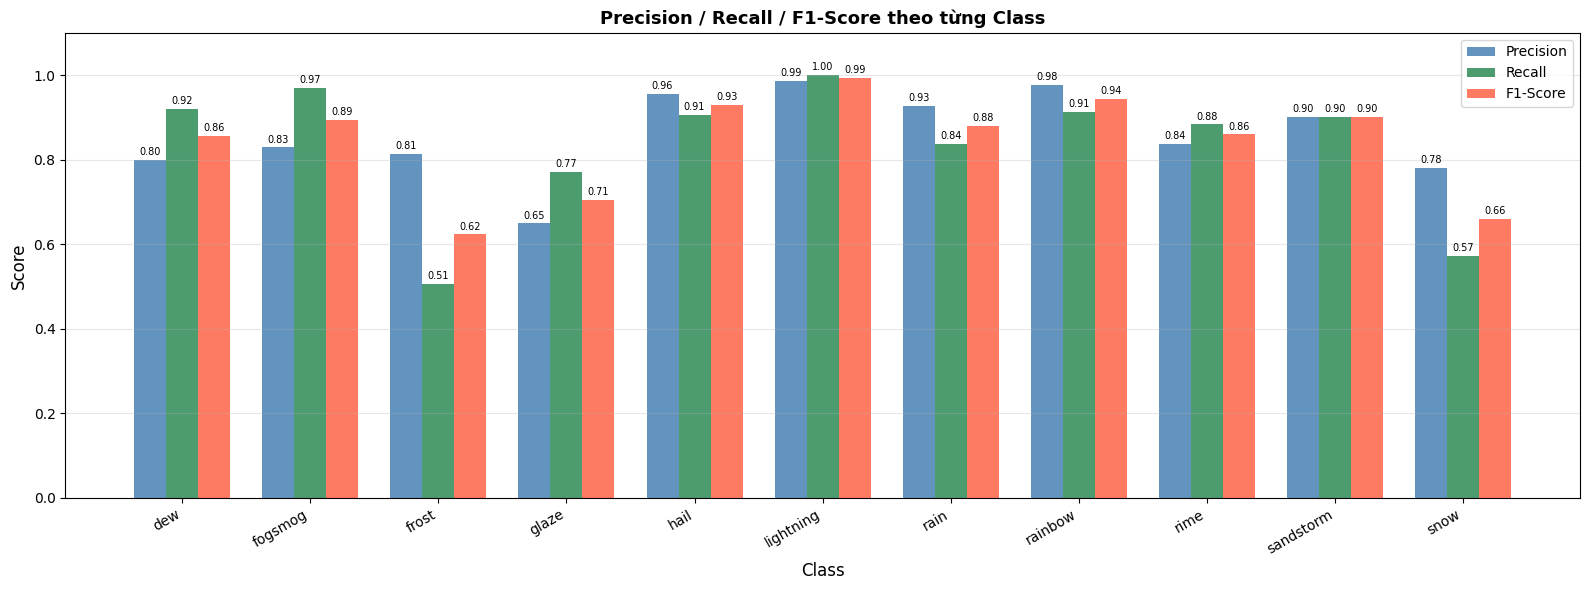


Support (số mẫu thực tế trong validation) theo từng class:
  dew                       139 mẫu
  fogsmog                   170 mẫu
  frost                     95 mẫu
  glaze                     127 mẫu
  hail                      118 mẫu
  lightning                 75 mẫu
  rain                      105 mẫu
  rainbow                   46 mẫu
  rime                      232 mẫu
  sandstorm                 141 mẫu
  snow                      124 mẫu


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision_per, recall_per, f1_per, support_per = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)

x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, precision_per, width, label='Precision', color='steelblue', alpha=0.85)
bars2 = ax.bar(x,         recall_per,    width, label='Recall',    color='seagreen',  alpha=0.85)
bars3 = ax.bar(x + width, f1_per,        width, label='F1-Score',  color='tomato',    alpha=0.85)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1-Score theo từng Class', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Ghi giá trị lên cột
for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Bảng Support
print("\nSupport (số mẫu thực tế trong validation) theo từng class:")
for cls, sup in zip(CLASS_NAMES, support_per):
    print(f"  {cls:<25} {int(sup)} mẫu")

## 14. Dự đoán thử trên ảnh mẫu

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
SEED = 42
def predict_single_image(img_path, model, class_names, img_size=300):
    """Dự đoán một ảnh và hiển thị top-3 kết quả"""
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    x = keras_image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    preds = model.predict(x, verbose=0)[0]
    top3_idx = np.argsort(preds)[::-1][:3]

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    title = f"Dự đoán: {class_names[top3_idx[0]]} ({preds[top3_idx[0]]*100:.1f}%)"
    plt.title(title, fontsize=11)
    plt.axis('off')
    plt.show()

    print("Top-3 dự đoán:")
    for i, idx in enumerate(top3_idx):
        print(f"  {i+1}. {class_names[idx]:<25} {preds[idx]*100:.2f}%")

# Lấy ảnh mẫu đầu tiên từ mỗi class để test
print("Demo dự đoán trên 3 ảnh ngẫu nhiên:")
import random
random.seed(SEED)

sample_paths = []
for cls in random.sample(CLASS_NAMES, min(3, len(CLASS_NAMES))):
    cls_dir = os.path.join(DATASET_PATH, cls)
    imgs_in_cls = [f for f in os.listdir(cls_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs_in_cls:
        sample_paths.append(os.path.join(cls_dir, random.choice(imgs_in_cls)))

for path in sample_paths:
    print(f"\nẢnh: {path}")
    predict_single_image(path, model, CLASS_NAMES, IMG_SIZE)

Demo dự đoán trên 3 ảnh ngẫu nhiên:

Ảnh: /content/drive/MyDrive/dataset/snow/1112.jpg


NameError: name 'model' is not defined

## 15. Tóm tắt Kết quả

In [ ]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])

print("╔══════════════════════════════════════════════════╗")
print("║          TÓM TẮT KẾT QUẢ MÔ HÌNH              ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Epoch tốt nhất       : {best_epoch:<24}║")
print(f"║  Val Accuracy cao nhất: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)       ║")
print(f"║  Test Accuracy        : {acc:.4f} ({acc*100:.2f}%)       ║")
print(f"║  Precision (weighted) : {precision:.4f}                   ║")
print(f"║  Recall    (weighted) : {recall:.4f}                   ║")
print(f"║  F1-Score  (weighted) : {f1:.4f}                   ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Model lưu tại: MyDrive/weather_cnn_best.keras  ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║          TÓM TẮT KẾT QUẢ MÔ HÌNH              ║
╠══════════════════════════════════════════════════╣
║  Epoch tốt nhất       : 49                      ║
║  Val Accuracy cao nhất: 0.8411 (84.11%)       ║
║  Test Accuracy        : 0.8411 (84.11%)       ║
║  Precision (weighted) : 0.8445                   ║
║  Recall    (weighted) : 0.8411                   ║
║  F1-Score  (weighted) : 0.8369                   ║
╠══════════════════════════════════════════════════╣
║  Model lưu tại: MyDrive/weather_cnn_best.keras  ║
╚══════════════════════════════════════════════════╝


## 16. Lưu model h5

In [ ]:
model.save('content/drive/MyDrive/weather_cnn_best.h5')

NameError: name 'model' is not defined

##17 . LoadModel và các bảng đánh giá

In [ ]:
IMG_SIZE     = 300
BATCH_SIZE   = 32
NUM_CLASSES  = 11
SEED         = 42
VAL_SPLIT    = 0.2

MODEL_PATH = '/content/drive/MyDrive/weather_cnn_best.h5'  # <-- sửa đường dẫn tại đây

print("Cấu hình đã được thiết lập!")

Cấu hình đã được thiết lập!


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False,
    classes=['dew', 'fogsmog', 'frost', 'glaze', 'hail',
             'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']  # chỉ định rõ class, bỏ .ipynb_checkpoints
)

CLASS_NAMES = ['dew', 'fogsmog', 'frost', 'glaze', 'hail',
               'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']

Found 1372 images belonging to 11 classes.


In [ ]:
import os

# ── Load model .h5 ────────────────────────────────────────────────────────────
model = keras.models.load_model(MODEL_PATH)
print(f"✅ Đã load model từ: {MODEL_PATH}")
print(f"Tổng tham số: {model.count_params():,}")
model.summary()

✅ Đã load model từ: /content/drive/MyDrive/weather_cnn_best.h5
Tổng tham số: 9,969,899


Model: "WeatherCNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 150, 150,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 150,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 150, 150,  │     18,432 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 75, 75,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 75, 75,    │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 75, 75,    │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 75, 75,    │      8,192 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 75, 75,    │          0 │ add[0][0]       

 Total params: 9,969,901 (38.03 MB)

 Trainable params: 9,960,747 (38.00 MB)

 Non-trainable params: 9,152 (35.75 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
val_generator.reset()

print("Đang dự đoán validation set...")

y_pred_proba = []
y_true = []

for i in range(len(val_generator)):
    X_batch, y_batch = val_generator[i]
    preds = model.predict(X_batch, verbose=0)
    y_pred_proba.append(preds)
    y_true.append(np.argmax(y_batch, axis=1))

y_pred_proba = np.concatenate(y_pred_proba, axis=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate(y_true, axis=0)

print(f"\nSố mẫu validation: {len(y_true)}")
print(f"Kiểm tra: y_true shape={y_true.shape}, y_pred shape={y_pred.shape}")
print(f"Phân bố y_true: {np.unique(y_true, return_counts=True)}")
print(f"Classes: {CLASS_NAMES}")

Đang dự đoán validation set...

Số mẫu validation: 1372
Kiểm tra: y_true shape=(1372,), y_pred shape=(1372,)
Phân bố y_true: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([139, 170,  95, 127, 118,  75, 105,  46, 232, 141, 124]))
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


##18 Classification Report

In [ ]:
# ── Metrics tổng quát ──────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("=" * 50)
print("       KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("=" * 50)
print(f"  Accuracy  (tổng): {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (weighted): {precision:.4f}")
print(f"  Recall    (weighted): {recall:.4f}")
print(f"  F1-Score  (weighted): {f1:.4f}")
print("=" * 50)

# ── Classification Report (per-class) ─────────────────────────────
print("\nClassification Report (Accuracy / Precision / Recall / F1 / Support theo từng class):")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

       KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
  Accuracy  (tổng): 0.8411  (84.11%)
  Precision (weighted): 0.8445
  Recall    (weighted): 0.8411
  F1-Score  (weighted): 0.8369

Classification Report (Accuracy / Precision / Recall / F1 / Support theo từng class):
              precision    recall  f1-score   support

         dew     0.8000    0.9209    0.8562       139
     fogsmog     0.8291    0.9706    0.8943       170
       frost     0.8136    0.5053    0.6234        95
       glaze     0.6490    0.7717    0.7050       127
        hail     0.9554    0.9068    0.9304       118
   lightning     0.9868    1.0000    0.9934        75
        rain     0.9263    0.8381    0.8800       105
     rainbow     0.9767    0.9130    0.9438        46
        rime     0.8367    0.8836    0.8595       232
   sandstorm     0.9007    0.9007    0.9007       141
        snow     0.7802    0.5726    0.6605       124

    accuracy                         0.8411      1372
   macro avg     0.8595    0.8348    0.8407    

##19 Confusion Matrix

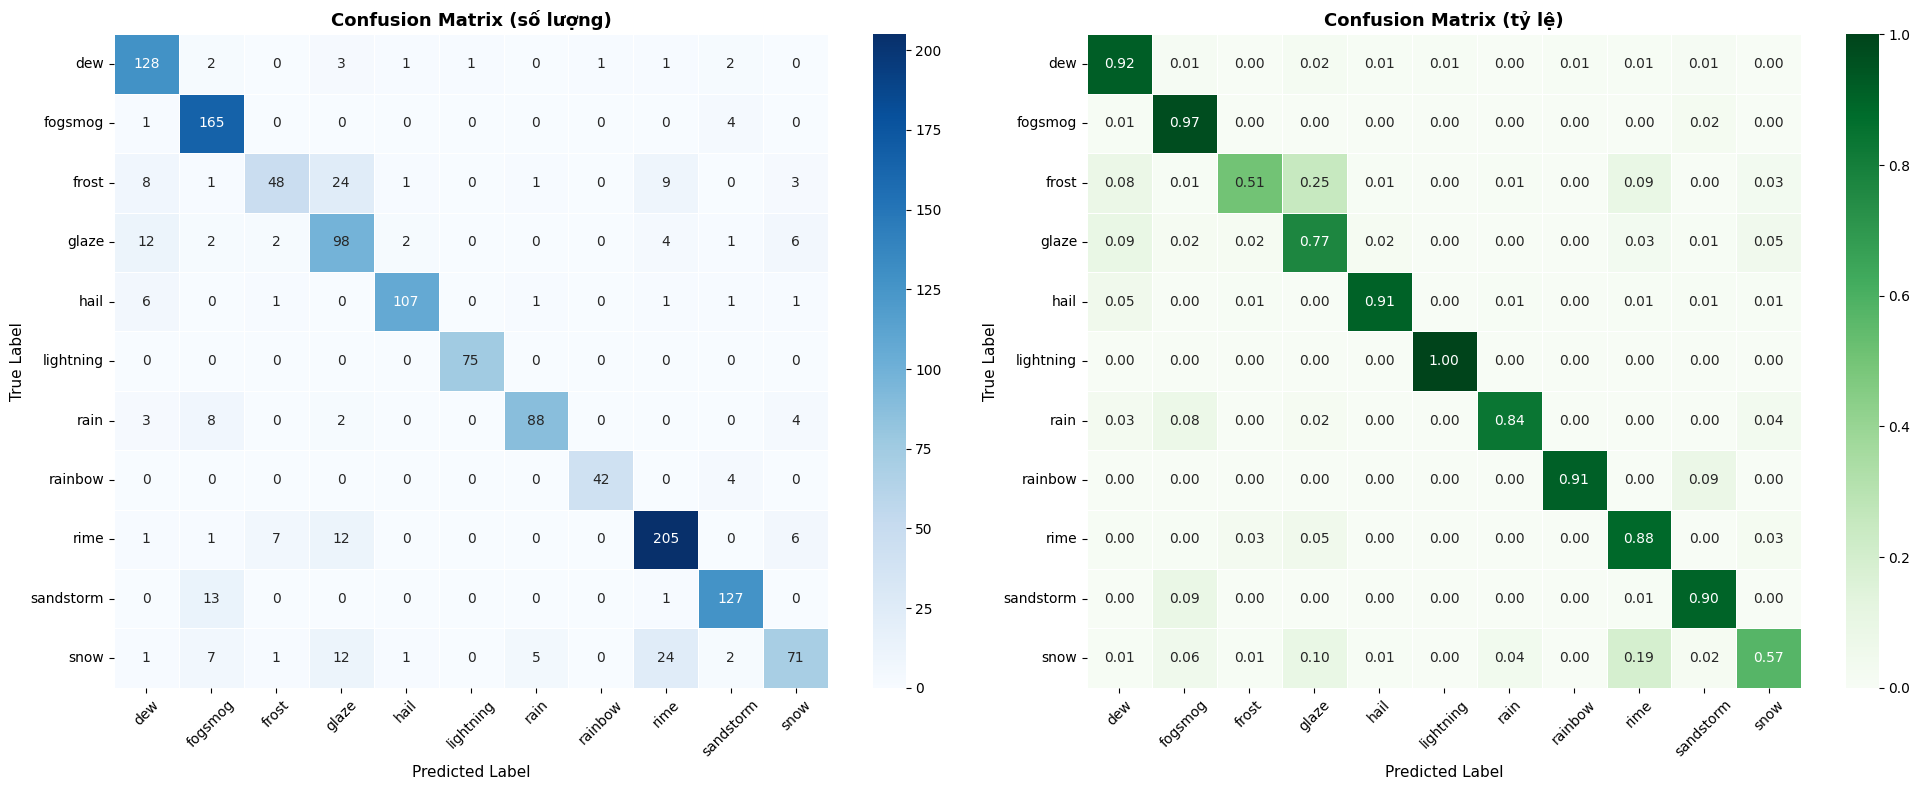

Đã lưu confusion matrix tại /content/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix (số lượng)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (số lượng)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Confusion Matrix (tỷ lệ %)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (tỷ lệ)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu confusion matrix tại /content/confusion_matrix.png")

##20 Biểu đồ Metrics theo từng Class

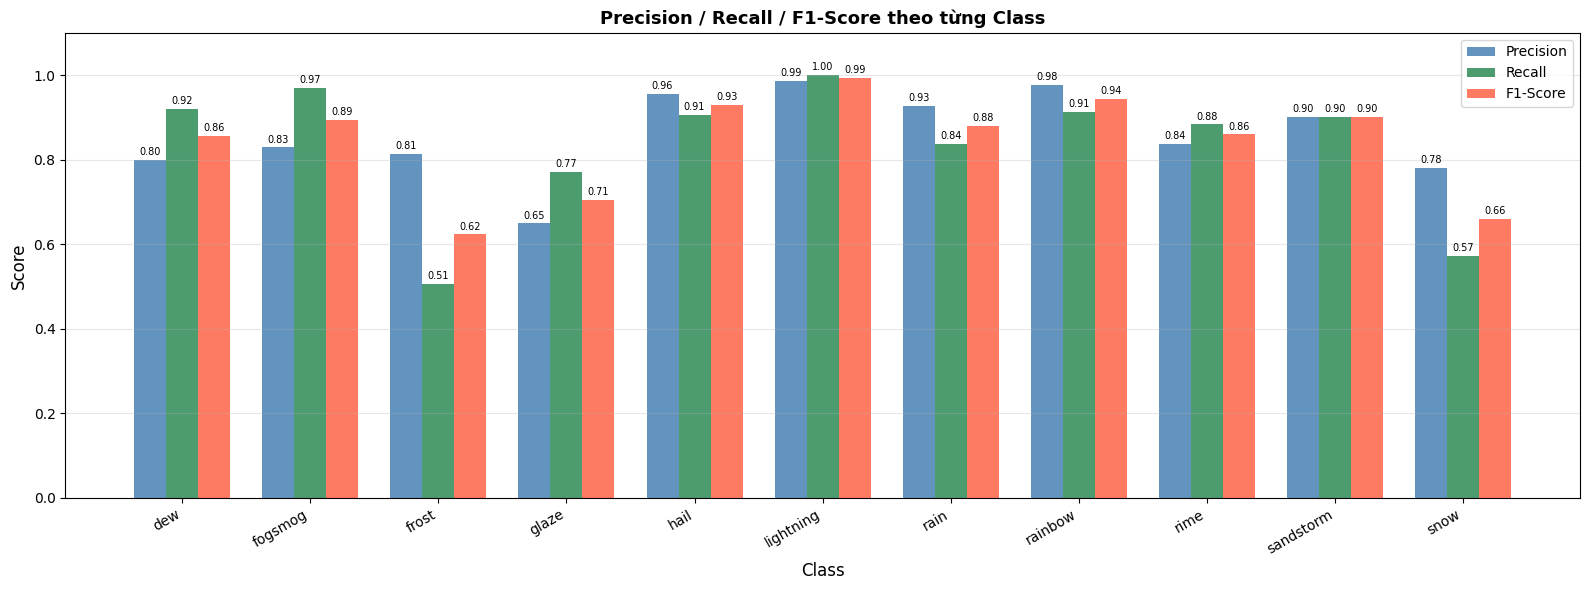


Support (số mẫu thực tế trong validation) theo từng class:
  dew                       139 mẫu
  fogsmog                   170 mẫu
  frost                     95 mẫu
  glaze                     127 mẫu
  hail                      118 mẫu
  lightning                 75 mẫu
  rain                      105 mẫu
  rainbow                   46 mẫu
  rime                      232 mẫu
  sandstorm                 141 mẫu
  snow                      124 mẫu


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision_per, recall_per, f1_per, support_per = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)

x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, precision_per, width, label='Precision', color='steelblue', alpha=0.85)
bars2 = ax.bar(x,         recall_per,    width, label='Recall',    color='seagreen',  alpha=0.85)
bars3 = ax.bar(x + width, f1_per,        width, label='F1-Score',  color='tomato',    alpha=0.85)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1-Score theo từng Class', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSupport (số mẫu thực tế trong validation) theo từng class:")
for cls, sup in zip(CLASS_NAMES, support_per):
    print(f"  {cls:<25} {int(sup)} mẫu")

##21 AUC – ROC Curve (OvR, macro & per-class)

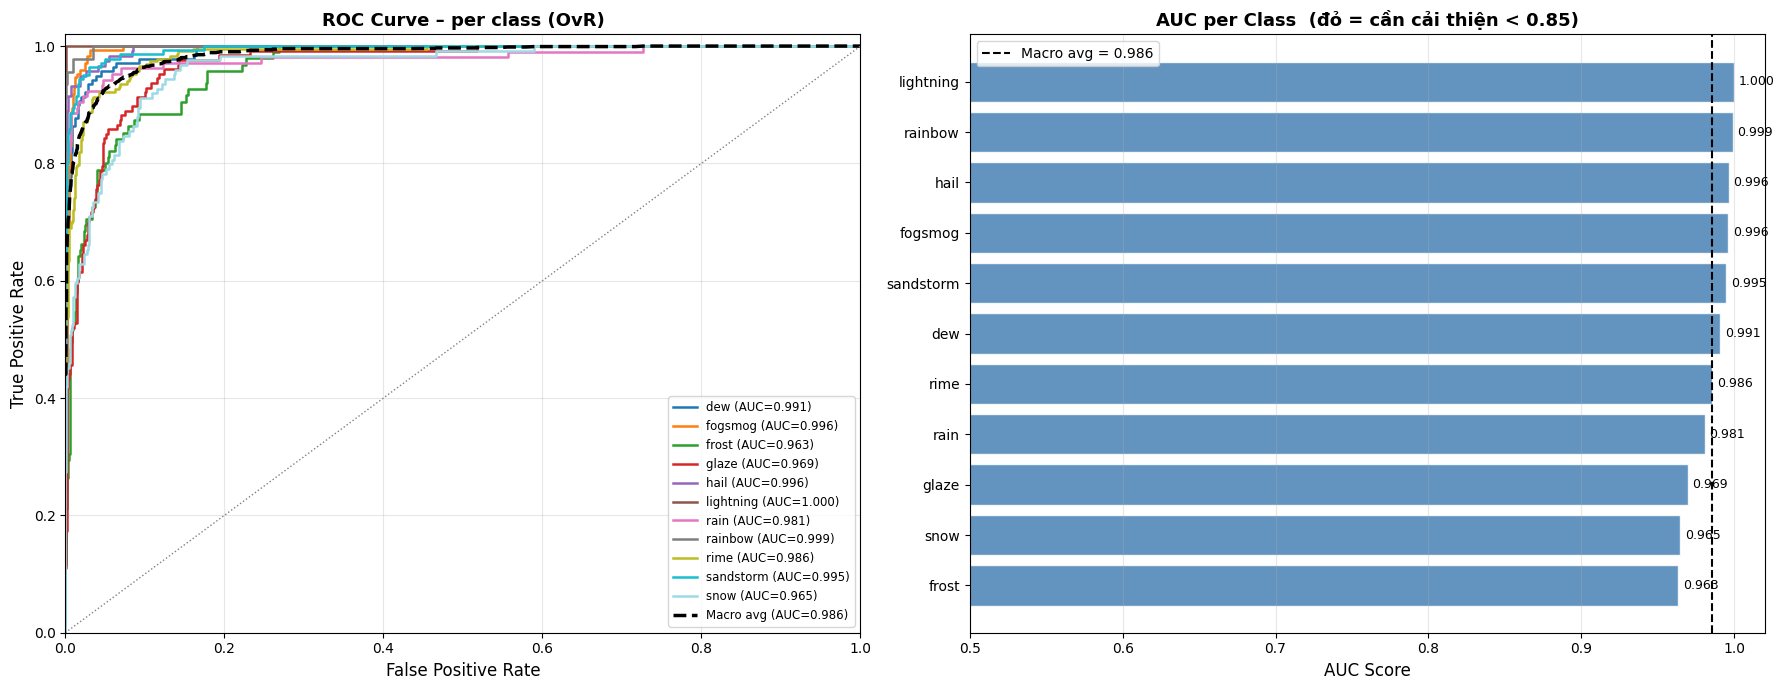


── AUC Score per Class ──────────────────────────────
  dew                       AUC = 0.9907  ✅
  fogsmog                   AUC = 0.9960  ✅
  frost                     AUC = 0.9633  ✅
  glaze                     AUC = 0.9694  ✅
  hail                      AUC = 0.9962  ✅
  lightning                 AUC = 1.0000  ✅
  rain                      AUC = 0.9806  ✅
  rainbow                   AUC = 0.9990  ✅
  rime                      AUC = 0.9857  ✅
  sandstorm                 AUC = 0.9947  ✅
  snow                      AUC = 0.9645  ✅

  Macro-avg AUC = 0.9855
Đã lưu biểu đồ ROC tại /content/roc_auc_curve.png


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ── Binarize labels cho OvR ────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

# ── Tính AUC từng class ────────────────────────────────────────────
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# ── Macro-average ROC ─────────────────────────────────────────────
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= NUM_CLASSES
roc_auc_macro = auc(all_fpr, mean_tpr)

# ── Vẽ ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = plt.cm.get_cmap('tab20', NUM_CLASSES).colors
for i in range(NUM_CLASSES):
    axes[0].plot(
        fpr_dict[i], tpr_dict[i],
        color=colors[i], lw=1.8,
        label=f'{CLASS_NAMES[i]} (AUC={roc_auc_dict[i]:.3f})'
    )
axes[0].plot(all_fpr, mean_tpr, 'k--', lw=2.5,
             label=f'Macro avg (AUC={roc_auc_macro:.3f})')
axes[0].plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve – per class (OvR)', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8.5)
axes[0].grid(alpha=0.3)

sorted_idx = np.argsort([roc_auc_dict[i] for i in range(NUM_CLASSES)])
bar_colors = ['tomato' if roc_auc_dict[i] < 0.85 else 'steelblue' for i in sorted_idx]
bars = axes[1].barh(
    [CLASS_NAMES[i] for i in sorted_idx],
    [roc_auc_dict[i] for i in sorted_idx],
    color=bar_colors, alpha=0.85, edgecolor='white'
)
axes[1].axvline(roc_auc_macro, color='black', lw=1.5, linestyle='--',
                label=f'Macro avg = {roc_auc_macro:.3f}')
axes[1].set_xlim([0.5, 1.02])
axes[1].set_xlabel('AUC Score', fontsize=12)
axes[1].set_title('AUC per Class  (đỏ = cần cải thiện < 0.85)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
for bar, idx in zip(bars, sorted_idx):
    axes[1].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{roc_auc_dict[idx]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── AUC Score per Class ──────────────────────────────")
for i, cls in enumerate(CLASS_NAMES):
    flag = "⚠️  cần cải thiện" if roc_auc_dict[i] < 0.85 else "✅"
    print(f"  {cls:<25} AUC = {roc_auc_dict[i]:.4f}  {flag}")
print(f"\n  Macro-avg AUC = {roc_auc_macro:.4f}")
print("Đã lưu biểu đồ ROC tại /content/roc_auc_curve.png")